# GSE146115: PGAM5-associated inferred macrophages in four HCC tumors

Fluidigm C1 HTSeq read counts, not UMI, from HCC1,HCC2,HCC5,HCC9 (3200 cells). Sixteen GEO records are 200-cell sequencing parts, not sixteen independent patients. The official zero-padded cell-header mapping is normalized and verified against all matrix columns.

92 external ERCC- spike-ins are removed before QC, normalization and testing; human ERCC1/2/etc remain. Missing counts occur only in removed spike-ins. Human source rows have unique synthetic row IDs, preserving 27 date-corrupted/ambiguous symbols without guessing or merging identities; ambiguous rows are flagged in full and candidate tables and excluded from clustering features.

QC: >=500 detected human gene rows and <20% RNR1+RNR2 mitochondrial-rRNA fraction. The source lacks a full mitochondrial gene set: this is a **partial lower-bound proxy**, not a complete mitochondrial fraction and not zero. This limits direct QC comparability with prior datasets.

No author cell-type labels are provided. Global clustering uses 2000 Seurat HVGs minus PGAM5/ambiguous symbols,30 PCs,15 neighbors,Leiden1,seed0. Myeloid-enriched global cluster4 is reclustered with1500HVGs,15PCs,10neighbors,Leiden0.6,seed0. Marker-inferred C1Q-rich macrophage subclusters0,1,2,4 are retained: C1QA>=90%,C1QB>=70%,C1QC>=50%,CD68>=70%,CSF1R>=25%,TYROBP>=60%,CD1C<10%,FCN1<75%. Mixed FCN1-rich subcluster3 is excluded. This is exploratory target-agnostic annotation, not a validated classifier or complete C1Q-low macrophage census.

PGAM5 raw read count>0 defines RNA detection, not protein positivity. All selected macrophages are pooled and normalized to10000+log1p. Wilcoxon with ties correction and BH across all27135 human source rows; FDR<0.05,|approximate log2FC|>=1,>=10% detection in either group. PGAM5 is retained in full/passing tables and excluded from up/down candidates. No patient pairing, depth matching or sample/depth covariates. Ribosomal genes remain eligible. Approximate folds use back-transformed mean log expression, not arithmetic means.

**Only17 PGAM5-detected cells remain**,16 from HCC2 and1 from HCC9. Five Wilcoxon up candidates are retained as requested. A supplementary two-sided Fisher exact detection-frequency test, BH across the same27135 rows, finds **zero non-PGAM5 genes and zero of five candidates passing FDR<0.05**. Fisher tests detection frequency, not full expression ranks, and does not replace primary results. Small-group asymptotic significance and patient imbalance limit signature inference.

ALB RNA is common in these inferred macrophages; mixed RNA, ambient RNA and doublets are unresolved. Candidate MS4A1 is a B-cell-associated transcript and should not be presented as proven macrophage-specific expression. No validated signature, causal mechanism, patient-level reproducibility or independent validation is claimed.

Sources: [GEO GSE146115](https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE146115), [official supplementary files](https://ftp.ncbi.nlm.nih.gov/geo/series/GSE146nnn/GSE146115/suppl/), PMID33531041.


In [1]:
from pathlib import Path
import json,numpy as np,pandas as pd,anndata as ad
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
import matplotlib.pyplot as plt
from IPython.display import display
R=Path.cwd();s=json.loads((R/'analysis_summary.json').read_text())
a=ad.read_h5ad(R/'macrophage_counts_QC.h5ad')
r=pd.read_csv(R/'GSE146115_HCC_tumor_PGAM5_full_DE.csv',index_col=0)
u=pd.read_csv(R/'GSE146115_HCC_tumor_PGAM5_upregulated.csv',index_col=0)
d=pd.read_csv(R/'GSE146115_HCC_tumor_PGAM5_downregulated.csv',index_col=0)
assert set(a.obs.Sample)=={'HCC1','HCC2','HCC5','HCC9'}
assert a.obs.n_genes.ge(500).all() and a.obs.pct_mt.lt(20).all()
assert a.obs_names.is_unique and a.var_names.is_unique
q=pd.read_csv(R/'cluster_annotation_decisions.csv',dtype={'cluster':str})
assert set(a.obs.leiden.astype(str))==set(q.loc[q.included_as_macrophage,'cluster'])
pg=np.flatnonzero(a.var.gene.eq('PGAM5'));assert len(pg)==1
pos=a.X[:,pg[0]].toarray().ravel()>0
assert np.array_equal(pos,a.obs.PGAM5_detected)
assert int(pos.sum())==s['PGAM5_positive_cells'] and int((~pos).sum())==s['PGAM5_undetected_cells']
assert len(a)==s['QC_inferred_macrophages']
assert np.allclose(multipletests(r.p_value,method='fdr_bh')[1],r.FDR,atol=1e-12)
eligible=r.FDR.lt(.05)&r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')
assert set(u.index)==set(r.index[eligible&r.log2FC.ge(1)])
assert set(d.index)==set(r.index[eligible&r.log2FC.le(-1)])
checks=[];totals=np.asarray(a.X.sum(axis=1)).ravel()
for i in u.index[:10]:
 raw=a.X[:,a.var_names.get_loc(i)].toarray().ravel();v=np.log1p(raw/totals*1e4)
 pv=mannwhitneyu(v[pos],v[~pos],method='asymptotic',alternative='two-sided',use_continuity=False).pvalue
 fc=np.log2((np.expm1(v[pos].mean())+1e-9)/(np.expm1(v[~pos].mean())+1e-9))
 assert np.isclose(pv,r.loc[i,'p_value'],rtol=.002,atol=1e-12)
 assert np.isclose(fc,r.loc[i,'log2FC'],atol=.002)
 assert np.isclose((raw[pos]>0).mean(),r.loc[i,'fraction_PGAM5_positive'])
 checks.append({'gene':r.loc[i,'gene'],'SciPy_p':pv,'Scanpy_p':r.loc[i,'p_value'],'recomputed_log2FC':fc,'reported_log2FC':r.loc[i,'log2FC']})
pd.DataFrame(checks).to_csv(R/'independent_calculation_checks.csv',index=False)
e=json.loads((R/'exact_detection_summary.json').read_text())
assert e['positive_cells']==17 and e['up_candidates_passing_Fisher_FDR005']==0
print('Scope, partial-proxy QC, annotation, raw grouping, BH and all candidate memberships verified.')
display(pd.read_csv(R/'upregulated_with_exact_detection_check.csv')[['gene','log2FC','FDR','detected_positive_cells','detected_undetected_cells','Fisher_BH_FDR']])
display(pd.DataFrame(checks));display(pd.Series(s,name='value').to_frame())
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':10,'axes.spines.top':False,'axes.spines.right':False,'figure.dpi':120,'savefig.bbox':'tight'})


Scope, partial-proxy QC, annotation, raw grouping, BH and all candidate memberships verified.


,gene,log2FC,FDR,detected_positive_cells,detected_undetected_cells,Fisher_BH_FDR
0,STK26,26.146130,0.013357,3,0,1.0
1,ZNF785,25.937098,0.013357,3,0,1.0
2,MS4A1,25.289976,0.013357,3,0,1.0
3,LINC01776,24.208027,0.013357,3,0,1.0
4,TOP3B,3.705749,0.030616,5,3,1.0


,gene,SciPy_p,Scanpy_p,recomputed_log2FC,reported_log2FC
0,STK26,0.000002,0.000002,26.146129,26.146130
1,ZNF785,0.000002,0.000002,25.937097,25.937098
2,MS4A1,0.000002,0.000002,25.289975,25.289976
3,LINC01776,0.000002,0.000002,24.208027,24.208027
4,TOP3B,0.000007,0.000007,3.705749,3.705749


,value
HCC_tumor_samples,4
HCC_tumor_patients,4
source_tumor_cells,3200
QC_tumor_cells,1712
QC_inferred_macrophages,141
PGAM5_positive_cells,17
PGAM5_undetected_cells,124
samples_with_macrophages,4
samples_with_positive_macrophages,2
tested_genes,27135


## Annotation audit

Macrophages are inferred from concordant C1Q, CSF1R and TYROBP expression rather than PGAM5. The chart also shows the excluded mixed FCN1-rich subcluster to make exclusions inspectable. These labels are exploratory and do not establish complete macrophage subtype coverage.


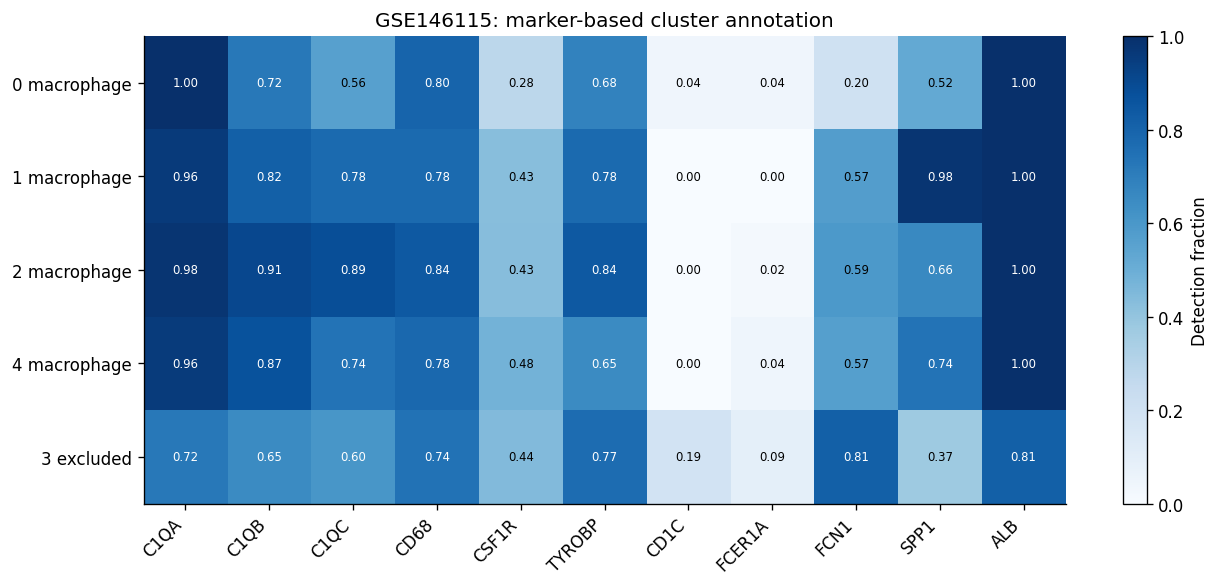

,cluster,cells,fraction_C1QA,fraction_C1QB,fraction_C1QC,fraction_CD68,fraction_CSF1R
0,0,25,1.000000,0.720000,0.560000,0.800000,0.280000
1,1,49,0.959184,0.816327,0.775510,0.775510,0.428571
2,2,44,0.977273,0.909091,0.886364,0.840909,0.431818
4,4,23,0.956522,0.869565,0.739130,0.782609,0.478261


In [2]:
q=pd.read_csv(R/'cluster_annotation_decisions.csv',dtype={'cluster':str})
cl=s['macrophage_clusters']+['3']
genes=['C1QA','C1QB','C1QC','CD68','CSF1R','TYROBP','CD1C','FCER1A','FCN1','SPP1','ALB']
t=q.set_index('cluster').loc[cl,['fraction_'+g for g in genes]]
fig,ax=plt.subplots(figsize=(11,5));im=ax.imshow(t.to_numpy(),vmin=0,vmax=1,cmap='Blues',aspect='auto')
ax.set_xticks(range(len(genes)),genes,rotation=45,ha='right')
ax.set_yticks(range(len(cl)),[i+(' macrophage' if i in s['macrophage_clusters'] else ' excluded') for i in cl])
for i in range(len(cl)):
 for j in range(len(genes)):
  z=t.iloc[i,j];ax.text(j,i,f'{z:.2f}',ha='center',va='center',fontsize=7,color='white' if z>.6 else 'black')
ax.set_title('GSE146115: marker-based cluster annotation');fig.colorbar(im,ax=ax,label='Detection fraction')
fig.tight_layout();fig.savefig(R/'cluster_annotation_QA.png');fig.savefig(R/'cluster_annotation_QA.pdf');plt.show()
display(q[q.included_as_macrophage][['cluster','cells']+['fraction_'+g for g in ['C1QA','C1QB','C1QC','CD68','CSF1R']]])


## PGAM5 detection support

All four HCC tumors are eligible. Rates use inferred macrophages as the denominator. Samples may contribute unequal numbers of cells; no balancing is performed.


,Sample,macrophages,PGAM5_positive,rate
0,HCC1,15,0,0.000000
1,HCC2,117,16,0.136752
2,HCC5,1,0,0.000000
3,HCC9,8,1,0.125000


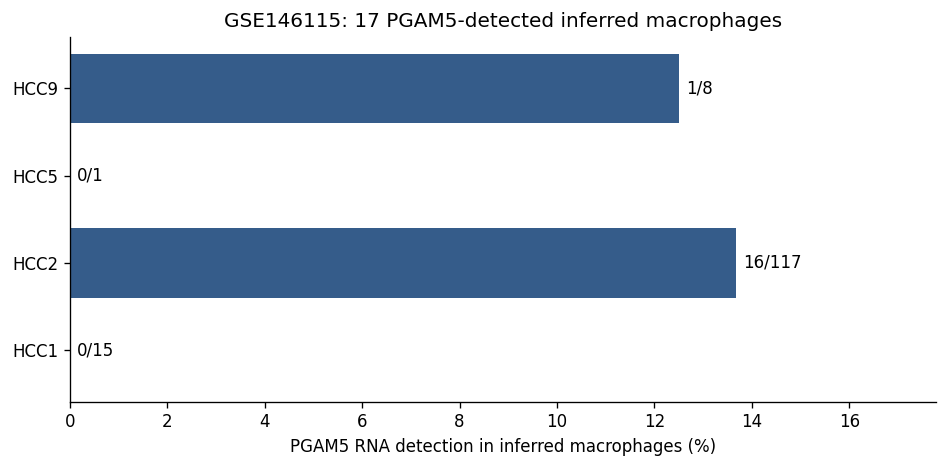

group,PGAM5_detected,PGAM5_undetected
gene,,
ALB,1.000,1.000
APOA1,1.000,0.984
C1QA,1.000,0.968
C1QB,0.941,0.823
C1QC,0.882,0.750
CD3D,0.000,0.073
CD68,0.941,0.782
CSF1R,0.588,0.387
EPCAM,0.000,0.008


In [3]:
t=pd.read_csv(R/'PGAM5_by_sample.csv');display(t)
fig,ax=plt.subplots(figsize=(8,4));ax.barh(t.Sample,t.rate*100,color='#355C8A')
for i,z in t.iterrows():ax.text(z.rate*100+.15,i,f'{z.PGAM5_positive}/{z.macrophages}',va='center')
ax.set_xlim(0,max(5,t.rate.max()*100*1.3));ax.set_xlabel('PGAM5 RNA detection in inferred macrophages (%)')
ax.set_title('GSE146115: 17 PGAM5-detected inferred macrophages');fig.tight_layout()
fig.savefig(R/'PGAM5_detection_by_sample.png');fig.savefig(R/'PGAM5_detection_by_sample.pdf');plt.show()
display(pd.read_csv(R/'TAM_marker_QA.csv').pivot(index='gene',columns='group',values='fraction').round(3))


## Differential candidates

Volcano includes genes detected in >=10% of either group, excluding the defining PGAM5 gene. Orange/blue denote up/down candidates; gray denotes others. Gene candidates may reflect technical or patient/subtype differences and unresolved ambient RNA.


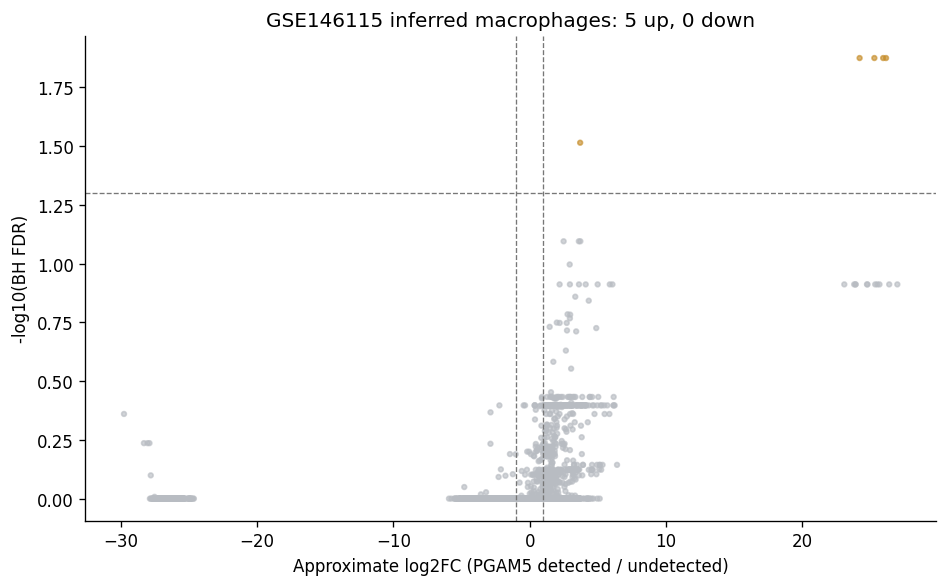

,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,
row_23455,STK26,26.146130,0.013357,0.176471,0.000000
row_26995,ZNF785,25.937098,0.013357,0.176471,0.000000
row_16365,MS4A1,25.289976,0.013357,0.176471,0.000000
row_11166,LINC01776,24.208027,0.013357,0.176471,0.000000
row_24781,TOP3B,3.705749,0.030616,0.294118,0.024194


,gene,log2FC,FDR,fraction_PGAM5_positive,fraction_PGAM5_undetected
names,,,,,


In [4]:
t=r[r[['fraction_PGAM5_positive','fraction_PGAM5_undetected']].max(axis=1).ge(.1)&~r.gene.eq('PGAM5')]
color=np.where(t.FDR.lt(.05)&t.log2FC.ge(1),'#C68D29',np.where(t.FDR.lt(.05)&t.log2FC.le(-1),'#355C8A','#B8BCC2'))
fig,ax=plt.subplots(figsize=(8,5));ax.scatter(t.log2FC,-np.log10(t.FDR.clip(lower=1e-300)),s=8,c=color,alpha=.65)
ax.axhline(-np.log10(.05),ls='--',color='#777',lw=.8)
for x in [-1,1]:ax.axvline(x,ls='--',color='#777',lw=.8)
ax.set_xlabel('Approximate log2FC (PGAM5 detected / undetected)');ax.set_ylabel('-log10(BH FDR)')
ax.set_title(f'GSE146115 inferred macrophages: {len(u)} up, {len(d)} down')
fig.tight_layout();fig.savefig(R/'differential_expression.png');fig.savefig(R/'differential_expression.pdf');plt.show()
display(u[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))
display(d[['gene','log2FC','FDR','fraction_PGAM5_positive','fraction_PGAM5_undetected']].head(20))


## Reproduction and limits

Download the count matrix, raw-to-processed mapping and family SOFT into the script directory. Install environment_versions.txt. Run prepare_annotation.py, refine_myeloid.py, analyze_PGAM5.py, exact_detection_check.py, then build_notebook.py. The ZIP contains tables, annotation decisions, plots, input hashes, code and this executed notebook; raw and QC matrices are regenerated by scripts.

The five requested Wilcoxon candidates are exploratory. Only17 positives,16 from one patient, lack of exact-detection FDR support, incomplete mitochondrial QC, inferred annotation, date-corrupted source symbols and mixed RNA limit a robust signature claim. No enrichment, causal analysis or independent patient validation is claimed.
